# Differentiable REV2 — supervised end-to-end training

Unrolls the REV2 `F`/`R`/`G` iteration into a PyTorch computation graph and backprops the **cross-entropy loss on the true tertile label** through all K iterations.

**Learnable parameters (all shared across quarters):**
- `γ1, γ2` — scalars (softplus'd positive). Control fairness-vs-agreement balance in `R`.
- `b_u` — per-investor bias s.t. `F₀(u) = sigmoid(z(log AUM_u) + b_u)`. Investors unseen in a given quarter keep `F₀` throughout that quarter's iterations.
- `τ1, τ2` — ordinal cut points mapping `G` → 3-class log-probs.
- `log_α` — sharpness of the ordinal head.

**Classification head (ordinal threshold model, preserves class ordering):**
```
P(y ≥ 1) = σ(α (G − τ1))
P(y ≥ 2) = σ(α (G − τ2))
```

**Training scheme:** Train on many quarters with shared params, validate on one, test on held-out future quarters. Compare against vanilla (unsupervised) REV2 from `rev2_stock_ranking.ipynb`.

## Setup

In [14]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from dotenv import load_dotenv
from scipy.stats import kendalltau
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore", category=UserWarning)

for env_path in [Path.cwd() / ".env", Path.cwd().parent / ".env", Path.cwd().parent.parent / ".env"]:
    if env_path.exists():
        load_dotenv(env_path)
        print("Loaded .env from:", env_path.resolve())
        break

def project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ETL").is_dir():
            return p
    return cwd.parent.parent

ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ETL.gnn_db_pipeline.config import (
    TARGET_DB,
    TGT_CHANGED_HOLDINGS,
    TGT_CHANGED_STAS,
    TGT_CIK_AUM,
    TGT_STOCKS_RETURN,
)
from ETL.gnn_db_pipeline.db_connector import ConfigurablePostgresHandler

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

handler = ConfigurablePostgresHandler(TARGET_DB)
handler.connect()
print("Connected to", TARGET_DB)

2026-04-18 22:36:28 - ETL_Pipeline - INFO - Connected to PostgreSQL: postgres@127.0.0.1:5432/13FGNN


Loaded .env from: C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market\.env
Device: cuda
Connected to 13FGNN


## Config

Pick train / val / test quarters. Keep val + test in chronological order *after* the train window to avoid leakage.

In [15]:
TRAIN_QUARTERS = [
    (2020, 1), (2020, 2), (2020, 3), (2020, 4),
    (2021, 1), (2021, 2), (2021, 3), (2021, 4),
    (2022, 1),             (2022, 3), (2022, 4),
]
VAL_QUARTERS  = [(2022, 2)]
TEST_QUARTERS = [(2023, 1), (2023, 2)]

WEIGHT_COL = "change_in_weight"   # or "change_in_adjusted_weight"
CLIP_BOUND = 1.0

K_ITER        = 10      # unrolled REV2 steps inside the forward pass
LR            = 1e-2
EPOCHS        = 60
WEIGHT_DECAY  = 1e-4
BIAS_INIT_STD = 0.01
SEED          = 42

torch.manual_seed(SEED); np.random.seed(SEED)
CLASS_NAMES = ["low", "mid", "high"]

## Data loaders (same queries as `rev2_stock_ranking.ipynb`)

In [16]:
def load_edges(year, quarter, weight_col="change_in_weight"):
    assert weight_col in ("change_in_weight", "change_in_adjusted_weight")
    q = f"""
        SELECT cik, cusip, {weight_col} AS w
        FROM {TGT_CHANGED_HOLDINGS}
        WHERE year = %s AND quarter = %s AND {weight_col} IS NOT NULL
    """
    return handler.query(q, (year, quarter))

def load_returns(year, quarter):
    q = f"""SELECT cusip, log_return FROM {TGT_STOCKS_RETURN}
            WHERE year = %s AND quarter = %s AND log_return IS NOT NULL"""
    return handler.query(q, (year, quarter))

def load_aum(year, quarter):
    q = f"""SELECT cik, total AS aum FROM {TGT_CIK_AUM}
            WHERE year = %s AND quarter = %s AND total > 0"""
    return handler.query(q, (year, quarter)).set_index("cik")["aum"]

def load_tertile_bounds(year, quarter):
    q = f"""SELECT log_return_tertile_1, log_return_tertile_2 FROM {TGT_CHANGED_STAS}
            WHERE year = %s AND quarter = %s"""
    row = handler.query(q, (year, quarter)).iloc[0]
    return float(row["log_return_tertile_1"]), float(row["log_return_tertile_2"])

def label_stocks(year, quarter):
    rets = load_returns(year, quarter)
    t1, t2 = load_tertile_bounds(year, quarter)
    rets = rets.copy()
    rets["true_class"] = np.where(
        rets["log_return"] <= t1, 0,
        np.where(rets["log_return"] <= t2, 1, 2),
    )
    return rets[["cusip", "log_return", "true_class"]]

## Global investor index + AUM prior

`b_u` embeddings need a stable mapping from `cik` to a row index across all quarters. We also compute a fixed log-AUM z-score from the **train** quarters only (no leakage).

In [17]:
def collect_ciks(quarters, weight_col):
    s = set()
    for (y, q) in quarters:
        s.update(load_edges(y, q, weight_col)["cik"].unique().tolist())
    return sorted(s)

def collect_mean_log_aum(quarters):
    dfs = [load_aum(y, q).rename(f"{y}Q{q}") for (y, q) in quarters]
    A = pd.concat(dfs, axis=1)
    return np.log(A).mean(axis=1)

ALL_QUARTERS = TRAIN_QUARTERS + VAL_QUARTERS + TEST_QUARTERS
GLOBAL_CIKS  = collect_ciks(ALL_QUARTERS, WEIGHT_COL)
cik_to_idx   = {c: i for i, c in enumerate(GLOBAL_CIKS)}
N_INVESTORS  = len(GLOBAL_CIKS)
print(f"Total unique investors across all quarters: {N_INVESTORS:,}")

LOG_AUM = collect_mean_log_aum(TRAIN_QUARTERS).reindex(GLOBAL_CIKS)
mu_aum, sigma_aum = LOG_AUM.mean(), LOG_AUM.std()
Z_AUM = ((LOG_AUM - mu_aum) / sigma_aum).fillna(0.0)
Z_AUM_TENSOR = torch.tensor(Z_AUM.values, dtype=torch.float32, device=DEVICE)
print(f"log AUM (train only):  μ={mu_aum:.2f}, σ={sigma_aum:.2f}")

Total unique investors across all quarters: 7,829
log AUM (train only):  μ=18.74, σ=2.22


## Per-quarter tensor bundles

In [18]:
def build_quarter(year, quarter, weight_col=WEIGHT_COL, clip_bound=CLIP_BOUND):
    edges  = load_edges(year, quarter, weight_col)
    edges["w"] = edges["w"].clip(-clip_bound, clip_bound)
    labels = label_stocks(year, quarter)
    edges  = edges[edges["cik"].isin(cik_to_idx)]

    cusips = pd.Index(edges["cusip"].unique())
    cusip_to_idx = {c: i for i, c in enumerate(cusips)}

    u_idx = edges["cik"].map(cik_to_idx).to_numpy()
    p_idx = edges["cusip"].map(cusip_to_idx).to_numpy()
    w     = edges["w"].to_numpy()

    labels = labels[labels["cusip"].isin(cusip_to_idx)].copy()
    labels["p_idx"] = labels["cusip"].map(cusip_to_idx)

    return {
        "u_idx":        torch.tensor(u_idx, dtype=torch.long,   device=DEVICE),
        "p_idx":        torch.tensor(p_idx, dtype=torch.long,   device=DEVICE),
        "w":            torch.tensor(w,     dtype=torch.float32, device=DEVICE),
        "n_p":          len(cusips),
        "label_p_idx":  torch.tensor(labels["p_idx"].values,      dtype=torch.long,    device=DEVICE),
        "label_y":      torch.tensor(labels["true_class"].values, dtype=torch.long,    device=DEVICE),
        "log_return":   torch.tensor(labels["log_return"].values, dtype=torch.float32, device=DEVICE),
        "cusips":       cusips.tolist(),
        "tag":          f"{year}Q{quarter}",
    }

print("Building per-quarter tensors...")
TRAIN_DATA = [build_quarter(y, q) for (y, q) in TRAIN_QUARTERS]
VAL_DATA   = [build_quarter(y, q) for (y, q) in VAL_QUARTERS]
TEST_DATA  = [build_quarter(y, q) for (y, q) in TEST_QUARTERS]
for d in TRAIN_DATA + VAL_DATA + TEST_DATA:
    print(f"  {d['tag']:>8}:  edges={d['u_idx'].shape[0]:>7,}   n_p={d['n_p']:>5,}   n_labeled={d['label_y'].shape[0]:>5,}")

Building per-quarter tensors...
    2020Q1:  edges=931,295   n_p=3,048   n_labeled=3,003
    2020Q2:  edges=915,339   n_p=3,023   n_labeled=2,984
    2020Q3:  edges=913,065   n_p=3,027   n_labeled=2,979
    2020Q4:  edges=942,296   n_p=3,069   n_labeled=2,985
    2021Q1:  edges=1,014,486   n_p=3,084   n_labeled=3,009
    2021Q2:  edges=1,031,993   n_p=3,116   n_labeled=3,037
    2021Q3:  edges=1,036,235   n_p=3,188   n_labeled=3,094
    2021Q4:  edges=1,054,087   n_p=3,230   n_labeled=3,124
    2022Q1:  edges=1,127,571   n_p=3,165   n_labeled=3,091
    2022Q3:  edges=1,075,334   n_p=3,123   n_labeled=3,090
    2022Q4:  edges=1,076,312   n_p=3,104   n_labeled=3,058
    2022Q2:  edges=1,104,392   n_p=3,149   n_labeled=3,114
    2023Q1:  edges=1,107,881   n_p=3,057   n_labeled=3,017
    2023Q2:  edges=1,108,027   n_p=3,014   n_labeled=2,983


## Differentiable REV2 module

`scatter_mean` reimplemented via `index_add_` so we don't need `torch_scatter`.

In each forward pass we rebuild `F_u` from the current `b_u` embeddings, run K iterations of the F/R/G updates, then run the ordinal head on G.

In [19]:
def scatter_mean(src, index, dim_size):
    out = torch.zeros(dim_size, dtype=src.dtype, device=src.device)
    cnt = torch.zeros(dim_size, dtype=src.dtype, device=src.device)
    out.index_add_(0, index, src)
    cnt.index_add_(0, index, torch.ones_like(src))
    return out / cnt.clamp(min=1.0)


class DifferentiableREV2(nn.Module):
    def __init__(self, n_investors, z_aum, k_iter=10, bias_init_std=0.01):
        super().__init__()
        self.n_investors = n_investors
        self.k_iter      = k_iter
        self.b_u = nn.Embedding(n_investors, 1)
        nn.init.normal_(self.b_u.weight, std=bias_init_std)
        # softplus(0.54) ≈ 1.0 — matches vanilla REV2 default
        self.gamma1_raw  = nn.Parameter(torch.tensor(0.54))
        self.gamma2_raw  = nn.Parameter(torch.tensor(0.54))
        # cuts: τ1 learnable, τ2 = τ1 + softplus(gap) > τ1 always
        self.tau1        = nn.Parameter(torch.tensor(-0.01))
        self.tau_gap_raw = nn.Parameter(torch.tensor(-2.0))
        self.log_alpha   = nn.Parameter(torch.tensor(np.log(20.0)))
        self.register_buffer("z_aum", z_aum)

    @property
    def gamma1(self):   return F.softplus(self.gamma1_raw)
    @property
    def gamma2(self):   return F.softplus(self.gamma2_raw)
    @property
    def tau2(self):     return self.tau1 + F.softplus(self.tau_gap_raw)

    def compute_G(self, u_idx, p_idx, w, n_p):
        F0 = torch.sigmoid(self.z_aum + self.b_u.weight.squeeze(1))
        F_u = F0
        G_p = torch.zeros(n_p, device=w.device)
        g1, g2 = self.gamma1, self.gamma2
        denom  = g1 + g2

        present_mask = torch.zeros(self.n_investors, device=w.device)
        present_mask.index_add_(0, u_idx, torch.ones_like(w))
        present = present_mask > 0

        for _ in range(self.k_iter):
            agree = 1.0 - (w - G_p[p_idx]).abs() / 2.0
            R     = (g1 * F_u[u_idx] + g2 * agree) / denom
            G_p   = scatter_mean(R * w, p_idx, n_p)
            F_new = scatter_mean(R, u_idx, self.n_investors)
            # investors with no edges this quarter keep their F₀ prior
            F_u   = torch.where(present, F_new, F_u)
        return G_p, F_u

    def classify(self, G_p):
        alpha = torch.exp(self.log_alpha)
        t1, t2 = self.tau1, self.tau2
        p_ge1 = torch.sigmoid(alpha * (G_p - t1))
        p_ge2 = torch.sigmoid(alpha * (G_p - t2))
        probs = torch.stack([1 - p_ge1, p_ge1 - p_ge2, p_ge2], dim=1).clamp(min=1e-7)
        probs = probs / probs.sum(dim=1, keepdim=True)
        return torch.log(probs)

    def forward(self, d):
        G_p, F_u = self.compute_G(d["u_idx"], d["p_idx"], d["w"], d["n_p"])
        log_probs_all = self.classify(G_p)
        return log_probs_all[d["label_p_idx"]], G_p, F_u

## Training loop

One quarter = one gradient step. We shuffle quarter order each epoch. Track val metrics every 5 epochs and keep the best-F1 checkpoint.

In [20]:
def eval_data_list(model, data_list):
    model.eval()
    rows = []
    with torch.no_grad():
        for d in data_list:
            log_probs, G_p, _ = model(d)
            pred = log_probs.argmax(dim=1).cpu().numpy()
            y    = d["label_y"].cpu().numpy()
            Gl   = G_p[d["label_p_idx"]].cpu().numpy()
            lr   = d["log_return"].cpu().numpy()
            rows.append({
                "quarter":     d["tag"],
                "n":           len(y),
                "acc":         accuracy_score(y, pred),
                "macro_f1":    f1_score(y, pred, average="macro"),
                "kendall_tau": kendalltau(Gl, lr).statistic,
            })
    model.train()
    return pd.DataFrame(rows)

model  = DifferentiableREV2(N_INVESTORS, Z_AUM_TENSOR, k_iter=K_ITER,
                            bias_init_std=BIAS_INIT_STD).to(DEVICE)
optim_ = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history       = []
best_val_f1   = -np.inf
best_state    = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_loss = 0.0
    for i in np.random.permutation(len(TRAIN_DATA)):
        d = TRAIN_DATA[i]
        log_probs, _, _ = model(d)
        loss = F.nll_loss(log_probs, d["label_y"])
        optim_.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optim_.step()
        ep_loss += loss.item()
    ep_loss /= len(TRAIN_DATA)

    if epoch == 1 or epoch % 5 == 0:
        val_m  = eval_data_list(model, VAL_DATA)
        val_f1 = val_m["macro_f1"].mean()
        history.append({
            "epoch":      epoch,
            "train_loss": ep_loss,
            "val_acc":    val_m["acc"].mean(),
            "val_f1":     val_f1,
            "val_tau":    val_m["kendall_tau"].mean(),
            "gamma1":     model.gamma1.item(),
            "gamma2":     model.gamma2.item(),
            "tau1":       model.tau1.item(),
            "tau2":       model.tau2.item(),
            "alpha":      torch.exp(model.log_alpha).item(),
        })
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.detach().clone() for k, v in model.state_dict().items()}
            tag = " *best*"
        else:
            tag = ""
        print(f"ep {epoch:3d} | loss={ep_loss:.4f} | val acc={val_m['acc'].mean():.4f} "
              f"F1={val_f1:.4f} τ={val_m['kendall_tau'].mean():+.3f} | "
              f"γ1={model.gamma1.item():.3f} γ2={model.gamma2.item():.3f} "
              f"cuts=[{model.tau1.item():+.4f}, {model.tau2.item():+.4f}]{tag}")

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nRestored best-val checkpoint (val F1 = {best_val_f1:.4f})")
hist_df = pd.DataFrame(history)

ep   1 | loss=1.1962 | val acc=0.3337 F1=0.1679 τ=+0.436 | γ1=0.941 γ2=0.938 cuts=[-0.0821, +0.0333] *best*
ep   5 | loss=1.0951 | val acc=0.4602 F1=0.3963 τ=+0.436 | γ1=0.802 γ2=0.767 cuts=[-0.0467, +0.0499] *best*
ep  10 | loss=1.0949 | val acc=0.3873 F1=0.2910 τ=+0.436 | γ1=0.741 γ2=0.684 cuts=[-0.0491, +0.0472]
ep  15 | loss=1.0949 | val acc=0.3764 F1=0.2714 τ=+0.436 | γ1=0.731 γ2=0.662 cuts=[-0.0483, +0.0474]
ep  20 | loss=1.0949 | val acc=0.4287 F1=0.3420 τ=+0.436 | γ1=0.725 γ2=0.662 cuts=[-0.0497, +0.0453]
ep  25 | loss=1.0948 | val acc=0.3751 F1=0.2691 τ=+0.436 | γ1=0.726 γ2=0.661 cuts=[-0.0476, +0.0467]
ep  30 | loss=1.0948 | val acc=0.4088 F1=0.3314 τ=+0.436 | γ1=0.722 γ2=0.664 cuts=[-0.0479, +0.0454]
ep  35 | loss=1.0947 | val acc=0.3802 F1=0.2794 τ=+0.436 | γ1=0.726 γ2=0.660 cuts=[-0.0466, +0.0458]
ep  40 | loss=1.0947 | val acc=0.3963 F1=0.3095 τ=+0.436 | γ1=0.722 γ2=0.664 cuts=[-0.0469, +0.0445]
ep  45 | loss=1.0947 | val acc=0.3661 F1=0.2442 τ=+0.436 | γ1=0.729 γ2=0.658 

## Training curves

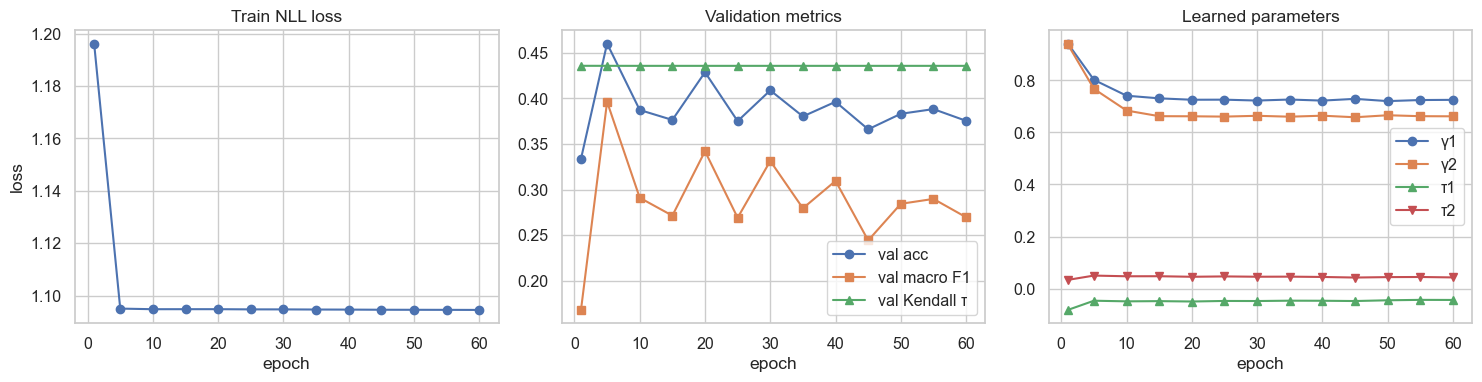

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o")
axes[0].set_title("Train NLL loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")

axes[1].plot(hist_df["epoch"], hist_df["val_acc"],  marker="o", label="val acc")
axes[1].plot(hist_df["epoch"], hist_df["val_f1"],   marker="s", label="val macro F1")
axes[1].plot(hist_df["epoch"], hist_df["val_tau"],  marker="^", label="val Kendall τ")
axes[1].set_title("Validation metrics"); axes[1].set_xlabel("epoch"); axes[1].legend()

axes[2].plot(hist_df["epoch"], hist_df["gamma1"], marker="o", label="γ1")
axes[2].plot(hist_df["epoch"], hist_df["gamma2"], marker="s", label="γ2")
axes[2].plot(hist_df["epoch"], hist_df["tau1"],   marker="^", label="τ1")
axes[2].plot(hist_df["epoch"], hist_df["tau2"],   marker="v", label="τ2")
axes[2].set_title("Learned parameters"); axes[2].set_xlabel("epoch"); axes[2].legend()

plt.tight_layout(); plt.show()

## Test-set evaluation

In [22]:
test_m = eval_data_list(model, TEST_DATA)
print(test_m.to_string(index=False))
print(f"\nMean:  acc={test_m['acc'].mean():.4f}  macro_f1={test_m['macro_f1'].mean():.4f}  kendall={test_m['kendall_tau'].mean():+.4f}")

quarter    n      acc  macro_f1  kendall_tau
 2023Q1 3017 0.437852  0.379211     0.426209
 2023Q2 2983 0.436809  0.375858     0.406223

Mean:  acc=0.4373  macro_f1=0.3775  kendall=+0.4162


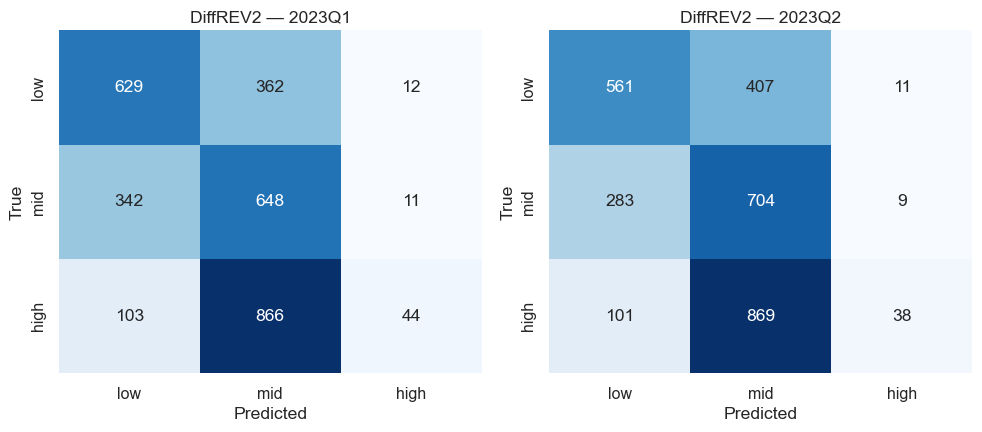

In [23]:
model.eval()
n = len(TEST_DATA)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), squeeze=False)
with torch.no_grad():
    for ax, d in zip(axes[0], TEST_DATA):
        log_probs, _, _ = model(d)
        pred = log_probs.argmax(dim=1).cpu().numpy()
        y    = d["label_y"].cpu().numpy()
        cm   = confusion_matrix(y, pred, labels=[0, 1, 2])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    cbar=False, ax=ax)
        ax.set_title(f"DiffREV2 — {d['tag']}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

## Baseline comparison — vanilla (unsupervised) REV2

Run the fixed-point REV2 (no supervision) on each test quarter and compare with the supervised model.

In [24]:
def goodness_baseline_np(edges):
    return edges.groupby("cusip", as_index=False)["w"].mean().rename(columns={"w": "G"})

def rev2_vanilla(edges, gamma1=1.0, gamma2=1.0, max_iter=100, tol=1e-6):
    e      = edges.copy()
    ciks   = pd.Index(e["cik"].unique())
    cusips = pd.Index(e["cusip"].unique())
    F_ = pd.Series(0.5, index=ciks)
    G_ = pd.Series(0.0, index=cusips)
    for _ in range(max_iter):
        f_u  = e["cik"].map(F_).to_numpy()
        g_p  = e["cusip"].map(G_).to_numpy()
        agr  = 1 - np.abs(e["w"].to_numpy() - g_p) / 2
        R    = (gamma1 * f_u + gamma2 * agr) / (gamma1 + gamma2)
        e["R"]  = R
        e["RW"] = R * e["w"]
        G_new = e.groupby("cusip")["RW"].mean().reindex(cusips).fillna(0.0)
        F_new = e.groupby("cik")["R"].mean().reindex(ciks).fillna(0.5)
        if max(np.max(np.abs(G_new - G_)), np.max(np.abs(F_new - F_))) < tol:
            F_, G_ = F_new, G_new; break
        F_, G_ = F_new, G_new
    return G_

def pred_from_G_series(G_series, cusips_labeled):
    vals = G_series.reindex(cusips_labeled).fillna(G_series.median()).values
    return pd.qcut(vals, 3, labels=[0, 1, 2], duplicates="drop").astype(int)

comp_rows = []
for (y, q), d in zip(TEST_QUARTERS, TEST_DATA):
    model.eval()
    with torch.no_grad():
        log_probs, G_diff, _ = model(d)
    pred_diff = log_probs.argmax(dim=1).cpu().numpy()
    y_true    = d["label_y"].cpu().numpy()
    lr_np     = d["log_return"].cpu().numpy()
    G_diff_lbl = G_diff[d["label_p_idx"]].cpu().numpy()

    e_df = load_edges(y, q, WEIGHT_COL)
    e_df["w"] = e_df["w"].clip(-CLIP_BOUND, CLIP_BOUND)
    cusips_lbl = [d["cusips"][i] for i in d["label_p_idx"].cpu().numpy()]

    G_base = goodness_baseline_np(e_df).set_index("cusip")["G"]
    G_van  = rev2_vanilla(e_df)

    pred_base = pred_from_G_series(G_base, cusips_lbl)
    pred_van  = pred_from_G_series(G_van,  cusips_lbl)

    comp_rows.append({
        "quarter":  d["tag"],
        "n":        len(y_true),
        "baseline_acc":  accuracy_score(y_true, pred_base),
        "baseline_f1":   f1_score(y_true, pred_base, average="macro"),
        "baseline_tau":  kendalltau(G_base.reindex(cusips_lbl).values, lr_np).statistic,
        "vanilla_acc":   accuracy_score(y_true, pred_van),
        "vanilla_f1":    f1_score(y_true, pred_van,  average="macro"),
        "vanilla_tau":   kendalltau(G_van.reindex(cusips_lbl).values,  lr_np).statistic,
        "diff_acc":      accuracy_score(y_true, pred_diff),
        "diff_f1":       f1_score(y_true, pred_diff, average="macro"),
        "diff_tau":      kendalltau(G_diff_lbl, lr_np).statistic,
    })

comp_df = pd.DataFrame(comp_rows)
comp_df

,quarter,n,baseline_acc,baseline_f1,baseline_tau,vanilla_acc,vanilla_f1,vanilla_tau,diff_acc,diff_f1,diff_tau
0,2023Q1,3017,0.565462,0.565230,0.418942,0.569108,0.568875,0.426212,0.437852,0.379211,0.426209
1,2023Q2,2983,0.558833,0.558696,0.398012,0.561180,0.561089,0.406248,0.436809,0.375858,0.406223


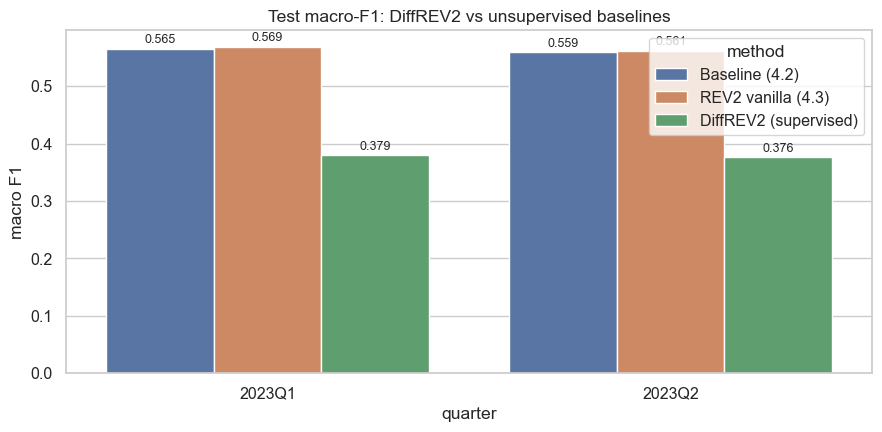

In [25]:
melt = comp_df.melt(id_vars=["quarter"],
                    value_vars=["baseline_f1", "vanilla_f1", "diff_f1"],
                    var_name="method", value_name="macro_f1")
melt["method"] = melt["method"].map({
    "baseline_f1": "Baseline (4.2)",
    "vanilla_f1":  "REV2 vanilla (4.3)",
    "diff_f1":     "DiffREV2 (supervised)",
})

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(melt, x="quarter", y="macro_f1", hue="method", ax=ax)
ax.set_title("Test macro-F1: DiffREV2 vs unsupervised baselines")
ax.set_ylabel("macro F1")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=9, padding=2)
plt.tight_layout(); plt.show()

## What did the model learn?

Inspect: (a) learned `γ1/γ2` ratio, (b) distribution of `b_u` biases, (c) how the learned fairness prior `F₀ = σ(z + b_u)` differs from the pure-AUM prior `σ(z)`.

Learned hyperparams:
  γ1 = 0.8019
  γ2 = 0.7673
  γ1 / γ2 = 1.0451  (>1 → trust investor fairness more; <1 → trust agreement-with-G more)
  τ1 = -0.0467
  τ2 = +0.0499
  α  = 14.533  (ordinal head sharpness)


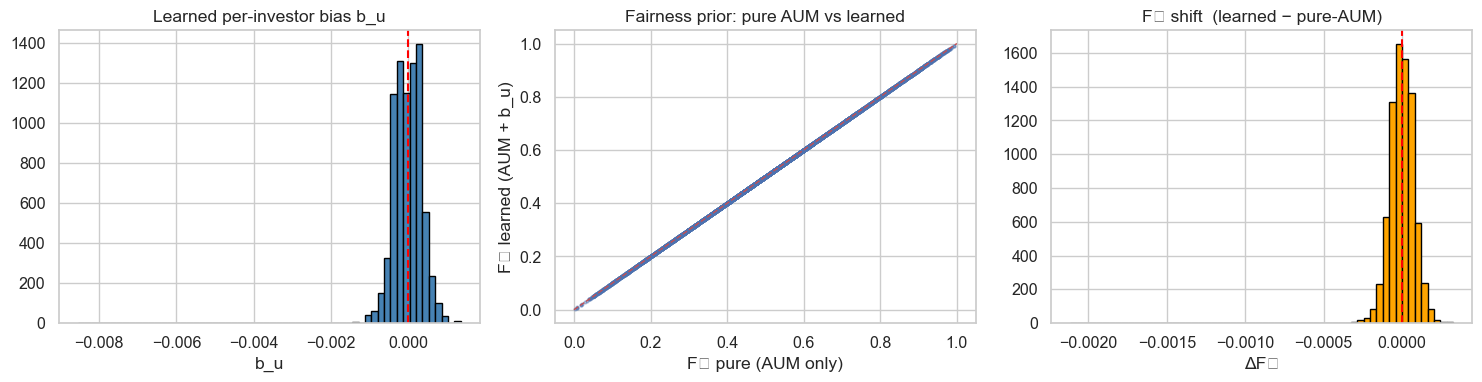


|ΔF₀| > 0.05 for 0 of 7,829 investors — these are the funds whose supervised 'skill' diverges most from size.


In [26]:
print(f"Learned hyperparams:")
print(f"  γ1 = {model.gamma1.item():.4f}")
print(f"  γ2 = {model.gamma2.item():.4f}")
print(f"  γ1 / γ2 = {(model.gamma1 / model.gamma2).item():.4f}  "
      f"(>1 → trust investor fairness more; <1 → trust agreement-with-G more)")
print(f"  τ1 = {model.tau1.item():+.4f}")
print(f"  τ2 = {model.tau2.item():+.4f}")
print(f"  α  = {torch.exp(model.log_alpha).item():.3f}  (ordinal head sharpness)")

b_u = model.b_u.weight.detach().cpu().numpy().squeeze()
z   = Z_AUM.values
F0_pure    = 1.0 / (1.0 + np.exp(-z))
F0_learned = 1.0 / (1.0 + np.exp(-(z + b_u)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(b_u, bins=60, color="steelblue", edgecolor="black")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Learned per-investor bias b_u"); axes[0].set_xlabel("b_u")

axes[1].scatter(F0_pure, F0_learned, s=4, alpha=0.4)
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1)
axes[1].set_xlabel("F₀ pure (AUM only)"); axes[1].set_ylabel("F₀ learned (AUM + b_u)")
axes[1].set_title("Fairness prior: pure AUM vs learned")

shift = F0_learned - F0_pure
axes[2].hist(shift, bins=60, color="orange", edgecolor="black")
axes[2].axvline(0, color="red", linestyle="--")
axes[2].set_title("F₀ shift  (learned − pure-AUM)"); axes[2].set_xlabel("ΔF₀")

plt.tight_layout(); plt.show()

print(f"\n|ΔF₀| > 0.05 for {(np.abs(shift) > 0.05).sum():,} of {len(shift):,} investors "
      f"— these are the funds whose supervised 'skill' diverges most from size.")

## Next steps

- **Try `change_in_adjusted_weight`**: flip `WEIGHT_COL` at the top and re-run. If it helps the unsupervised variants (per `rev2_stock_ranking.ipynb`), it should help here too.
- **Richer head**: replace the ordinal threshold head with a small MLP on `[G, |In(p)|, sector_id, ...]` — gives a supervised signal on graph features beyond G alone.
- **Learnable per-edge gate**: add `g(u,p) = σ(MLP(F_u, w))` as a multiplier on `R` — lets the model down-weight noisy edges from specific investors.
- **Multi-quarter batching**: currently 1 quarter = 1 grad step. With larger graphs, chunk edges within a quarter for variance reduction.
- **Rolling retraining**: for each test quarter `t`, retrain on quarters `[t-8, t-1]` to avoid leakage from the distant past.